## YOLOv8n

In [19]:
# Install ultralytics library if you haven't already
%pip install ultralytics

import cv2
from ultralytics import YOLO

# Pretrained classes in the model (COCO dataset classes for YOLOv8)
# YOLOv8 uses a different class index mapping than the previous model
classNames = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear',
    'hair drier', 'toothbrush'
]

# Loading YOLOv8n model trained on COCO data
model = YOLO('yolov8n.pt')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [25]:
image = cv2.imread("/content/green_light.jpg")

# Check if the image was loaded successfully
if image is None:
    print("Error: Could not load image.")
else:
    image_height, image_width, _ = image.shape

    # Perform inference using the YOLO model
    results = model(image)

    # The results object contains the detections. You can print it to see its structure.
    # print(results)


0: 480x640 3 cars, 1 bus, 5 trucks, 4 traffic lights, 74.0ms
Speed: 3.0ms preprocess, 74.0ms inference, 9.4ms postprocess per image at shape (1, 3, 480, 640)


In [17]:
# Rotate the image by 90 degrees clockwise
# Note: Rotation should ideally be done before inference if the model is sensitive to orientation.
# However, keeping it here as per original cell order.
image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

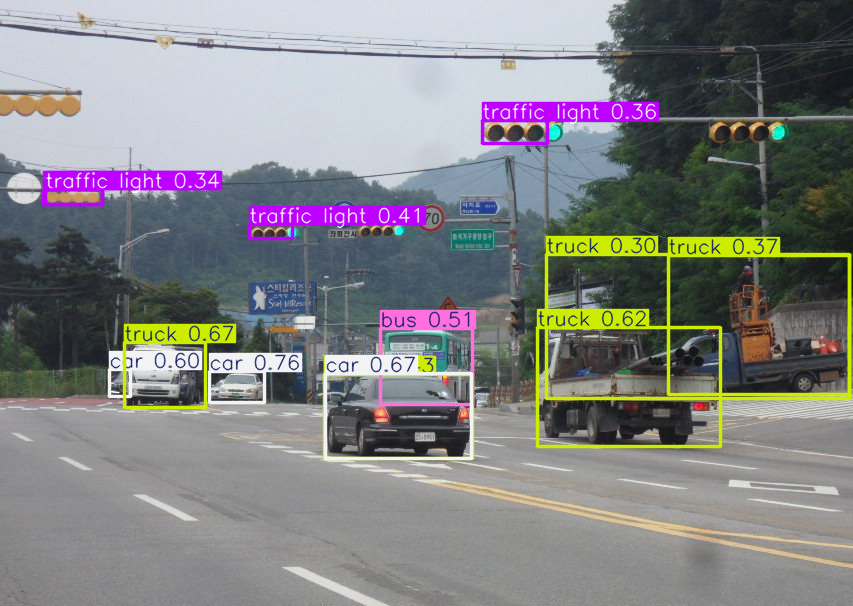

In [26]:
from google.colab.patches import cv2_imshow

# Process the results from the YOLO model
# The 'results' object contains a list of Results objects, one for each image.
# For a single image, we access the first element.
if 'results' in locals() and results is not None and len(results) > 0:
    processed_image = results[0].plot() # YOLO provides a convenient plot method

    cv2_imshow(processed_image)
    # cv2.imwrite("image_box_text.jpg",processed_image)

    # cv2.waitKey(0) # Not typically needed with cv2_imshow in Colab
    # cv2.destroyAllWindows() # Not typically needed with cv2_imshow in Colab
else:
    print("No results to display.")
    # If the image was loaded but no results were generated, show the original image
    if 'image' in locals() and image is not None:
         cv2_imshow(image)

In [27]:
import cv2
import numpy as np

def traffic_light_process(image, model, classNames):
    """
    Detects traffic lights in an image, determines their color, and returns a value.

    Args:
        image: The input image (numpy array).
        model: The loaded DNN model for object detection.
        classNames: A dictionary mapping class IDs to class names.

    Returns:
        0: Red light
        1: Green light
        2: Yellow light
        -1: No traffic light detected or color not determined
    """
    image_height, image_width, _ = image.shape

    model.setInput(cv2.dnn.blobFromImage(image, size=(300, 300), swapRB=True))
    output = model.forward()

    for detection in output[0, 0, :, :]:
        confidence = detection[2]
        class_id = int(detection[1])
        class_name = id_class_name(class_id, classNames)

        if confidence > 0.5 and class_name == "traffic light":
            box_x = int(detection[3] * image_width)
            box_y = int(detection[4] * image_height)
            box_width = int(detection[5] * image_width)
            box_height = int(detection[6] * image_height)

            # Extract the region of interest (ROI) for the traffic light
            roi = image[box_y:box_height, box_x:box_width]

            # Analyze the ROI to determine the color
            # This is a simplified approach and might need refinement
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

            # Define color ranges for red, green, and yellow in HSV
            # These ranges might need adjustment based on lighting conditions
            lower_red1 = np.array([0, 100, 100])
            upper_red1 = np.array([10, 255, 255])
            lower_red2 = np.array([160, 100, 100])
            upper_red2 = np.array([180, 255, 255])
            lower_green = np.array([40, 40, 40])
            upper_green = np.array([80, 255, 255])
            lower_yellow = np.array([20, 100, 100])
            upper_yellow = np.array([40, 255, 255])

            # Create masks for each color
            mask_red1 = cv2.inRange(hsv_roi, lower_red1, upper_red1)
            mask_red2 = cv2.inRange(hsv_roi, lower_red2, upper_red2)
            mask_red = mask_red1 + mask_red2
            mask_green = cv2.inRange(hsv_roi, lower_green, upper_green)
            mask_yellow = cv2.inRange(hsv_roi, lower_yellow, upper_yellow)

            # Count the number of pixels for each color
            red_pixels = cv2.countNonZero(mask_red)
            green_pixels = cv2.countNonZero(mask_green)
            yellow_pixels = cv2.countNonZero(mask_yellow)

            # Determine the dominant color
            if red_pixels > green_pixels and red_pixels > yellow_pixels:
                return 0  # Red light
            elif green_pixels > red_pixels and green_pixels > yellow_pixels:
                return 1  # Green light
            elif yellow_pixels > red_pixels and yellow_pixels > green_pixels:
                return 2  # Yellow light

    return -1 # No traffic light detected or color not determined

# You would need to load the model and classNames outside this function
# Example usage (assuming model and classNames are loaded):
# traffic_light_status = traffic_light_process(image, model, classNames)
# print("Traffic light status:", traffic_light_status)

# Call the traffic_light_process function
traffic_light_status = traffic_light_process(image, model, classNames)

# Print the result
print("Traffic light status:", traffic_light_status)

AttributeError: 'DetectionModel' object has no attribute 'setInput'

## SSD-MobilenetV2

In [28]:
import cv2

# Pretrained classes in the model
classNames = {0: 'background',
              1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane', 6: 'bus',
              7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light', 11: 'fire hydrant',
              13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat',
              18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear',
              24: 'zebra', 25: 'giraffe', 27: 'backpack', 28: 'umbrella', 31: 'handbag',
              32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard',
              37: 'sports ball', 38: 'kite', 39: 'baseball bat', 40: 'baseball glove',
              41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle',
              46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 50: 'spoon',
              51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange',
              56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 60: 'donut',
              61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed',
              67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse',
              75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave', 79: 'oven',
              80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book', 85: 'clock',
              86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'}


def id_class_name(class_id, classes):
    for key, value in classes.items():
        if class_id == key:
            return value


In [29]:
# Loading model
model = cv2.dnn.readNetFromTensorflow('/content/frozen_inference_graph.pb',
                                      '/content/ssd_mobilenet_v2_coco_2018_03_29.pbtxt')
image = cv2.imread("/content/green_light.jpg")

image_height, image_width, _ = image.shape

model.setInput(cv2.dnn.blobFromImage(image, size=(300, 300), swapRB=True))
output = model.forward()
# print(output[0,0,:,:].shape)

3.0 0.6943493 car
8.0 0.57925236 truck
3.0 0.5043695 car


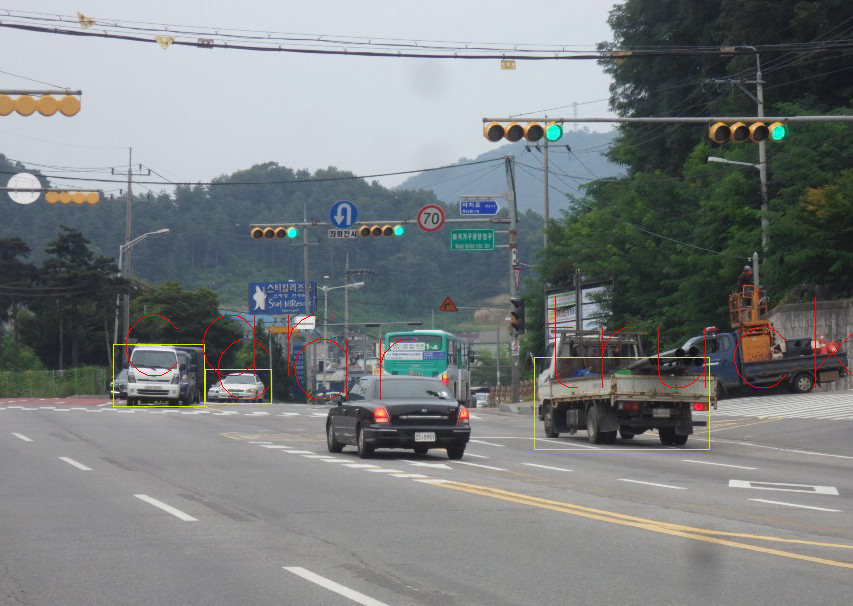

In [31]:
from google.colab.patches import cv2_imshow

for detection in output[0, 0, :, :]:
    confidence = detection[2]
    if confidence > .5:
        class_id = detection[1]
        class_name=id_class_name(class_id,classNames)
        print(str(str(class_id) + " " + str(detection[2])  + " " + class_name))
        box_x = detection[3] * image_width
        box_y = detection[4] * image_height
        box_width = detection[5] * image_width
        box_height = detection[6] * image_height
        cv2.rectangle(image, (int(box_x), int(box_y)), (int(box_width), int(box_height)), (23, 230, 210), thickness=1)
        cv2.putText(image,class_name ,(int(box_x), int(box_y+.05*image_height)),cv2.FONT_HERSHEY_SIMPLEX,(.005*image_width),(0, 0, 255))

cv2_imshow(image)
# cv2.imwrite("image_box_text.jpg",image)

# cv2.waitKey(0) # Not typically needed with cv2_imshow in Colab
# cv2.destroyAllWindows() # Not typically needed with cv2_imshow in Colab

In [32]:
import cv2
import numpy as np

def traffic_light_process(image, model, classNames):
    """
    Detects traffic lights in an image, determines their color, and returns a value.

    Args:
        image: The input image (numpy array).
        model: The loaded DNN model for object detection.
        classNames: A dictionary mapping class IDs to class names.

    Returns:
        0: Red light
        1: Green light
        2: Yellow light
        -1: No traffic light detected or color not determined
    """
    image_height, image_width, _ = image.shape

    model.setInput(cv2.dnn.blobFromImage(image, size=(300, 300), swapRB=True))
    output = model.forward()

    for detection in output[0, 0, :, :]:
        confidence = detection[2]
        class_id = int(detection[1])
        class_name = id_class_name(class_id, classNames)

        if confidence > 0.5 and class_name == "traffic light":
            box_x = int(detection[3] * image_width)
            box_y = int(detection[4] * image_height)
            box_width = int(detection[5] * image_width)
            box_height = int(detection[6] * image_height)

            # Extract the region of interest (ROI) for the traffic light
            roi = image[box_y:box_height, box_x:box_width]

            # Analyze the ROI to determine the color
            # This is a simplified approach and might need refinement
            hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

            # Define color ranges for red, green, and yellow in HSV
            # These ranges might need adjustment based on lighting conditions
            lower_red1 = np.array([0, 100, 100])
            upper_red1 = np.array([10, 255, 255])
            lower_red2 = np.array([160, 100, 100])
            upper_red2 = np.array([180, 255, 255])
            lower_green = np.array([40, 40, 40])
            upper_green = np.array([80, 255, 255])
            lower_yellow = np.array([20, 100, 100])
            upper_yellow = np.array([40, 255, 255])

            # Create masks for each color
            mask_red1 = cv2.inRange(hsv_roi, lower_red1, upper_red1)
            mask_red2 = cv2.inRange(hsv_roi, lower_red2, upper_red2)
            mask_red = mask_red1 + mask_red2
            mask_green = cv2.inRange(hsv_roi, lower_green, upper_green)
            mask_yellow = cv2.inRange(hsv_roi, lower_yellow, upper_yellow)

            # Count the number of pixels for each color
            red_pixels = cv2.countNonZero(mask_red)
            green_pixels = cv2.countNonZero(mask_green)
            yellow_pixels = cv2.countNonZero(mask_yellow)

            # Determine the dominant color
            if red_pixels > green_pixels and red_pixels > yellow_pixels:
                return 0  # Red light
            elif green_pixels > red_pixels and green_pixels > yellow_pixels:
                return 1  # Green light
            elif yellow_pixels > red_pixels and yellow_pixels > green_pixels:
                return 2  # Yellow light

    return -1 # No traffic light detected or color not determined

# You would need to load the model and classNames outside this function
# Example usage (assuming model and classNames are loaded):
# traffic_light_status = traffic_light_process(image, model, classNames)
# print("Traffic light status:", traffic_light_status)

# Call the traffic_light_process function
traffic_light_status = traffic_light_process(image, model, classNames)

# Print the result
print("Traffic light status:", traffic_light_status)

Traffic light status: -1
